In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = 12
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_for_test"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [51]:

ion_mode=[1,-1]
num_per_group=[1_000_000, 3_000_000, 10_000_000, 30_000_000, 100_000_000, 300_000_000]

In [52]:
df=[]
for group_size in num_per_group:
    data={"num_per_group":group_size,"number_of_spectra_per_file":1_000_000, "number_of_files":100}
    for charge in ion_mode:
        path_benchmark_specific_data_dynamic=path_benchmark_data/f"dynamic_fast_update_{charge}_compare_time_options_{group_size}_num_per_group.txt"
        
        with open(path_benchmark_specific_data_dynamic,"r") as f:
            dynamic=float(f.readline().strip())
            
        data["dynamic_entropy_search(fast_update)"]=dynamic
        data["charge"]=charge
        df.append(pd.DataFrame([data]))
    
df=pd.concat(df)
df

,num_per_group,number_of_spectra_per_file,number_of_files,dynamic_entropy_search(fast_update),charge
0,1000000,1000000,100,5484.844125,1
0,1000000,1000000,100,3421.934860,-1
0,3000000,1000000,100,6837.206392,1
0,3000000,1000000,100,4192.674532,-1
0,10000000,1000000,100,7088.934709,1
0,10000000,1000000,100,4166.112725,-1
0,30000000,1000000,100,7392.096598,1
0,30000000,1000000,100,4424.049296,-1
0,100000000,1000000,100,5201.256932,1
0,100000000,1000000,100,3200.898824,-1


In [53]:

df_data = df[["num_per_group", 
              "charge",
            "dynamic_entropy_search(fast_update)", 
            ]]

df_melted=df_data.melt(id_vars=["charge", "num_per_group"], var_name="type", value_name="time")
df_melted


,charge,num_per_group,type,time
0,1,1000000,dynamic_entropy_search(fast_update),5484.844125
1,-1,1000000,dynamic_entropy_search(fast_update),3421.934860
2,1,3000000,dynamic_entropy_search(fast_update),6837.206392
3,-1,3000000,dynamic_entropy_search(fast_update),4192.674532
4,1,10000000,dynamic_entropy_search(fast_update),7088.934709
5,-1,10000000,dynamic_entropy_search(fast_update),4166.112725
6,1,30000000,dynamic_entropy_search(fast_update),7392.096598
7,-1,30000000,dynamic_entropy_search(fast_update),4424.049296
8,1,100000000,dynamic_entropy_search(fast_update),5201.256932
9,-1,100000000,dynamic_entropy_search(fast_update),3200.898824


In [ ]:
def plot_time_options_num_per_group(
        df,
        color_palette,
        ylim,
        save_path

):
#     df_charge=df_melted[df_melted["charge"]==charge]
    plt.figure(figsize=(6, 4))
    sns.barplot(x="num_per_group", y="dynamic_entropy_search(fast_update)", hue="charge", data=df, 
                palette=color_palette, legend=True, width=0.4, errwidth=0)
    plt.ylabel("Index building time (seconds)")
    bottom=ylim[0]
    top=ylim[1]
    ax = plt.gca()
    current_labels = [int(label.get_text()) for label in ax.get_xticklabels()]
    new_labels = [f"{label:,}" for label in current_labels]
    ax.set_xticklabels(new_labels)
    plt.xticks(rotation=30)
    plt.ylim(top=top, bottom=bottom)
    plt.xlabel(f"Size of group")
    handles, labels = ax.get_legend_handles_labels()
    custom_labels = ['(+)ESI' if label == '1' else '(-)ESI' for label in labels]
    ax.legend(handles, custom_labels,loc='upper center',bbox_to_anchor=(0.5,1.2), framealpha=0.9, ncol=2,frameon=False, )
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)

In [55]:
color_palette={
    1: '#ca3032',
    -1:"#32586d"
}

/tmp/ipykernel_2734163/3546439143.py:10: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x="num_per_group", y="dynamic_entropy_search(fast_update)", hue="charge", data=df,
/tmp/ipykernel_2734163/3546439143.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


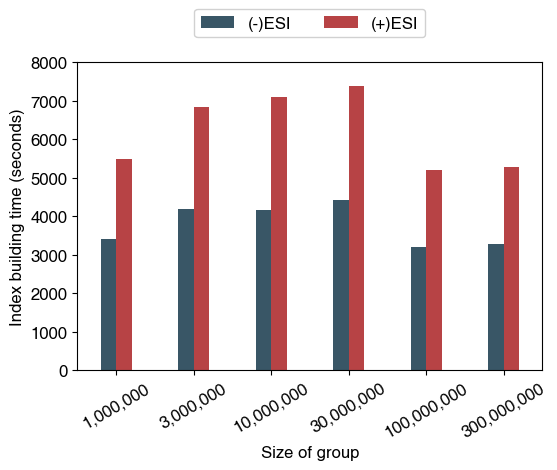

In [56]:
# charge=-1
ylim=(0,8000)
save_path=path_figures / f"compare_time_options_num_per_group.svg"
plot_time_options_num_per_group(
    df=df,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)

In [57]:
charge=1
ylim=(0,8000)
save_path=path_figures / f"compare_time_{charge}_options_num_per_group.svg"
plot_time_options_num_per_group(
    df_melted=df_melted,
    charge=charge,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)

TypeError: plot_time_options_num_per_group() got an unexpected keyword argument 'df_melted'